In [ ]:
# Notebook 6: Final results analysis for APS and YCB-28

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from IPython.display import display

PROJECT_DIR = Path("/content/drive/MyDrive/PointNet_APS_Project_V2")

RESULTS_DIR = PROJECT_DIR / "results_final"
RESULTS_XYZ_DIR = PROJECT_DIR / "results_final_xyz"

FIGURES_DIR = PROJECT_DIR / "figures_final_analysis"
TABLES_DIR = PROJECT_DIR / "final_analysis_tables"
VIS_DIR = FIGURES_DIR / "pointcloud_visualisations"
PLOTS_DIR = FIGURES_DIR / "summary_plots"
CM_PLOTS_DIR = FIGURES_DIR / "confusion_matrices"

for d in [FIGURES_DIR, TABLES_DIR, VIS_DIR, PLOTS_DIR, CM_PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["box", "cylinder", "sphere"]

print("Project directory:", PROJECT_DIR)
print("Final analysis figures:", FIGURES_DIR)
print("Final analysis tables:", TABLES_DIR)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/PointNet_APS_Project_V2
Final analysis figures: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis
Final analysis tables: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables


In [ ]:
# Result file paths from earlier notebooks

paths = {
    # Notebook 2/3: original APS experiment using XYZ + normals
    "old_aps_summary": RESULTS_DIR / "test_results" / "all_experiments_summary_runs_1_to_9.csv",

    # Notebook 5: original XYZ + normals models tested on YCB-28
    "old_ycb_summary": RESULTS_DIR / "ycb28_results" / "pointnetpp_aps_to_ycb28_summary_runs_1_to_9.csv",

    # Notebook 6: improved XYZ-only models tested on APS
    "new_aps_summary": RESULTS_XYZ_DIR / "aps_test_results" / "pointnetpp_xyz_aps_test_summary_runs.csv",
    "new_aps_predictions": RESULTS_XYZ_DIR / "aps_test_results" / "pointnetpp_xyz_aps_test_all_predictions_runs.csv",

    # Notebook 6: improved XYZ-only models tested on YCB-28
    "new_ycb_summary": RESULTS_XYZ_DIR / "ycb28_results" / "pointnetpp_xyz_aps_to_ycb28_summary_runs.csv",
    "new_ycb_predictions": RESULTS_XYZ_DIR / "ycb28_results" / "pointnetpp_xyz_aps_to_ycb28_all_predictions_runs.csv",

    # Notebook 6: overfitting/training records
    "new_training_records": RESULTS_XYZ_DIR / "statistics" / "xyz_pilot_training_records.csv",
    "new_checkpoint_check": RESULTS_XYZ_DIR / "statistics" / "xyz_checkpoint_availability.csv",
}

for name, path in paths.items():
    print(f"{name}: {path.exists()} -> {path}")

old_aps_summary: True -> /content/drive/MyDrive/PointNet_APS_Project_V2/results_final/test_results/all_experiments_summary_runs_1_to_9.csv
old_ycb_summary: True -> /content/drive/MyDrive/PointNet_APS_Project_V2/results_final/ycb28_results/pointnetpp_aps_to_ycb28_summary_runs_1_to_9.csv
new_aps_summary: True -> /content/drive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/aps_test_results/pointnetpp_xyz_aps_test_summary_runs.csv
new_aps_predictions: True -> /content/drive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/aps_test_results/pointnetpp_xyz_aps_test_all_predictions_runs.csv
new_ycb_summary: True -> /content/drive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/ycb28_results/pointnetpp_xyz_aps_to_ycb28_summary_runs.csv
new_ycb_predictions: True -> /content/drive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/ycb28_results/pointnetpp_xyz_aps_to_ycb28_all_predictions_runs.csv
new_training_records: True -> /content/drive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/

In [ ]:
# Load result files safely

def load_csv_if_exists(path, name):
    if Path(path).exists():
        df = pd.read_csv(path)
        print(f"Loaded {name}: {df.shape}")
        return df
    else:
        print(f"Missing {name}: {path}")
        return None

old_aps_df = load_csv_if_exists(paths["old_aps_summary"], "old APS summary")
old_ycb_df = load_csv_if_exists(paths["old_ycb_summary"], "old YCB summary")

new_aps_df = load_csv_if_exists(paths["new_aps_summary"], "new APS summary")
new_aps_pred_df = load_csv_if_exists(paths["new_aps_predictions"], "new APS predictions")

new_ycb_df = load_csv_if_exists(paths["new_ycb_summary"], "new YCB summary")
new_ycb_pred_df = load_csv_if_exists(paths["new_ycb_predictions"], "new YCB predictions")

new_training_records_df = load_csv_if_exists(paths["new_training_records"], "new training records")
checkpoint_check_df = load_csv_if_exists(paths["new_checkpoint_check"], "new checkpoint check")

print("\nLoaded files complete.")

Loaded old APS summary: (81, 11)
Loaded old YCB summary: (27, 13)
Loaded new APS summary: (81, 13)
Loaded new APS predictions: (48600, 18)
Loaded new YCB summary: (27, 13)
Loaded new YCB predictions: (15120, 20)
Loaded new training records: (27, 6)
Loaded new checkpoint check: (27, 4)

Loaded files complete.


In [ ]:
# Add experiment labels

def clean_condition_name(condition):
    condition = str(condition)

    if "clean" in condition:
        base = "Clean trained"
    elif "error" in condition:
        base = "Error trained"
    elif "mixed" in condition:
        base = "Mixed trained"
    else:
        base = condition

    return base


if old_aps_df is not None:
    old_aps_df["input_type"] = "XYZ + normals"
    old_aps_df["experiment"] = "Original PointNet++"
    old_aps_df["condition_label"] = old_aps_df["train_condition"].apply(clean_condition_name)

if old_ycb_df is not None:
    old_ycb_df["input_type"] = "XYZ + normals"
    old_ycb_df["experiment"] = "Original PointNet++"
    old_ycb_df["condition_label"] = old_ycb_df["train_condition"].apply(clean_condition_name)

if new_aps_df is not None:
    new_aps_df["input_type"] = "XYZ only"
    new_aps_df["experiment"] = "Improved PointNet++"
    new_aps_df["condition_label"] = new_aps_df["train_condition"].apply(clean_condition_name)

if new_ycb_df is not None:
    new_ycb_df["input_type"] = "XYZ only"
    new_ycb_df["experiment"] = "Improved PointNet++"
    new_ycb_df["condition_label"] = new_ycb_df["train_condition"].apply(clean_condition_name)

print("Labels added.")

Labels added.


In [ ]:
# Add experiment labels

def clean_condition_name(condition):
    condition = str(condition)

    if "clean" in condition:
        base = "Clean trained"
    elif "error" in condition:
        base = "Error trained"
    elif "mixed" in condition:
        base = "Mixed trained"
    else:
        base = condition

    return base


if old_aps_df is not None:
    old_aps_df["input_type"] = "XYZ + normals"
    old_aps_df["experiment"] = "Original PointNet++"
    old_aps_df["condition_label"] = old_aps_df["train_condition"].apply(clean_condition_name)

if old_ycb_df is not None:
    old_ycb_df["input_type"] = "XYZ + normals"
    old_ycb_df["experiment"] = "Original PointNet++"
    old_ycb_df["condition_label"] = old_ycb_df["train_condition"].apply(clean_condition_name)

if new_aps_df is not None:
    new_aps_df["input_type"] = "XYZ only"
    new_aps_df["experiment"] = "Improved PointNet++"
    new_aps_df["condition_label"] = new_aps_df["train_condition"].apply(clean_condition_name)

if new_ycb_df is not None:
    new_ycb_df["input_type"] = "XYZ only"
    new_ycb_df["experiment"] = "Improved PointNet++"
    new_ycb_df["condition_label"] = new_ycb_df["train_condition"].apply(clean_condition_name)

print("Labels added.")

Labels added.


In [ ]:
# APS result summary for original and improved experiments

aps_result_frames = []

if old_aps_df is not None:
    aps_result_frames.append(old_aps_df)

if new_aps_df is not None:
    aps_result_frames.append(new_aps_df)

aps_all_results_df = pd.concat(aps_result_frames, ignore_index=True)

aps_summary_table = (
    aps_all_results_df
    .groupby(["experiment", "input_type", "condition_label", "test_set"])
    .agg(
        mean_accuracy_percent=("test_accuracy_percent", "mean"),
        std_accuracy_percent=("test_accuracy_percent", "std"),
        min_accuracy_percent=("test_accuracy_percent", "min"),
        max_accuracy_percent=("test_accuracy_percent", "max"),
        mean_box_accuracy_percent=("box_accuracy_percent", "mean"),
        mean_cylinder_accuracy_percent=("cylinder_accuracy_percent", "mean"),
        mean_sphere_accuracy_percent=("sphere_accuracy_percent", "mean")
    )
    .reset_index()
    .round(4)
)

display(aps_summary_table)

aps_summary_path = TABLES_DIR / "final_aps_summary_table.csv"
aps_summary_table.to_csv(aps_summary_path, index=False)

print("Saved APS summary table:", aps_summary_path)

,experiment,input_type,condition_label,test_set,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,max_accuracy_percent,mean_box_accuracy_percent,mean_cylinder_accuracy_percent,mean_sphere_accuracy_percent
0,Improved PointNet++,XYZ only,Clean trained,aps_clean_test,100.0000,0.0000,100.0000,100.0000,100.0000,100.0000,100.0000
1,Improved PointNet++,XYZ only,Clean trained,aps_error_double_test,67.5185,12.4854,51.8333,84.8333,98.6111,51.1111,52.8333
2,Improved PointNet++,XYZ only,Clean trained,aps_error_test,99.8333,0.1179,99.6667,100.0000,99.9444,99.5556,100.0000
3,Improved PointNet++,XYZ only,Error trained,aps_clean_test,99.9630,0.0735,99.8333,100.0000,99.8889,100.0000,100.0000
4,Improved PointNet++,XYZ only,Error trained,aps_error_double_test,98.8704,0.9082,96.6667,99.8333,97.4444,99.1667,100.0000
5,Improved PointNet++,XYZ only,Error trained,aps_error_test,99.9074,0.1211,99.6667,100.0000,99.8333,99.8889,100.0000
6,Improved PointNet++,XYZ only,Mixed trained,aps_clean_test,99.9815,0.0556,99.8333,100.0000,99.9444,100.0000,100.0000
7,Improved PointNet++,XYZ only,Mixed trained,aps_error_double_test,98.8889,0.8333,97.3333,99.8333,97.6667,99.0000,100.0000
8,Improved PointNet++,XYZ only,Mixed trained,aps_error_test,99.9259,0.1690,99.5000,100.0000,99.7778,100.0000,100.0000
9,Original PointNet++,XYZ + normals,Clean trained,aps_clean_test,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved APS summary table: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_aps_summary_table.csv


In [ ]:
# YCB-28 result summary for old and improved experiments

ycb_result_frames = []

if old_ycb_df is not None:
    ycb_result_frames.append(old_ycb_df)

if new_ycb_df is not None:
    ycb_result_frames.append(new_ycb_df)

ycb_all_results_df = pd.concat(ycb_result_frames, ignore_index=True)

ycb_summary_table = (
    ycb_all_results_df
    .groupby(["experiment", "input_type", "condition_label", "test_set"])
    .agg(
        mean_accuracy_percent=("test_accuracy_percent", "mean"),
        std_accuracy_percent=("test_accuracy_percent", "std"),
        min_accuracy_percent=("test_accuracy_percent", "min"),
        max_accuracy_percent=("test_accuracy_percent", "max"),
        mean_box_accuracy_percent=("box_accuracy_percent", "mean"),
        mean_cylinder_accuracy_percent=("cylinder_accuracy_percent", "mean"),
        mean_sphere_accuracy_percent=("sphere_accuracy_percent", "mean")
    )
    .reset_index()
    .round(4)
)

display(ycb_summary_table)

ycb_summary_path = TABLES_DIR / "final_ycb28_summary_table.csv"
ycb_summary_table.to_csv(ycb_summary_path, index=False)

print("Saved YCB summary table:", ycb_summary_path)

,experiment,input_type,condition_label,test_set,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,max_accuracy_percent,mean_box_accuracy_percent,mean_cylinder_accuracy_percent,mean_sphere_accuracy_percent
0,Improved PointNet++,XYZ only,Clean trained,ycb28,83.0556,1.8971,80.7143,86.0714,87.9630,66.8056,90.8586
1,Improved PointNet++,XYZ only,Error trained,ycb28,86.5476,2.4091,83.0357,90.3571,87.4691,79.5139,90.9091
2,Improved PointNet++,XYZ only,Mixed trained,ycb28,89.1865,1.9027,85.7143,91.2500,88.7037,87.3611,90.9091
3,Original PointNet++,XYZ + normals,Clean trained,ycb28,66.0516,4.1921,61.9643,75.0000,55.4321,60.9028,78.4848
4,Original PointNet++,XYZ + normals,Error trained,ycb28,67.3214,4.5763,58.3929,73.3929,42.9012,72.4306,83.5859
5,Original PointNet++,XYZ + normals,Mixed trained,ycb28,67.1825,3.1451,63.3929,72.1429,45.8642,71.7361,81.3131


Saved YCB summary table: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_ycb28_summary_table.csv


In [ ]:
# Five-number summary function

def five_number_summary(df, group_cols, value_col="test_accuracy_percent"):
    summary = (
        df
        .groupby(group_cols)[value_col]
        .describe(percentiles=[0.25, 0.5, 0.75])
        .reset_index()
    )

    summary = summary.rename(columns={
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Maximum",
        "mean": "Mean",
        "std": "Std"
    })

    keep_cols = group_cols + ["Minimum", "Q1", "Median", "Q3", "Maximum", "Mean", "Std"]
    return summary[keep_cols].round(4)


aps_five_summary = five_number_summary(
    aps_all_results_df,
    ["experiment", "input_type", "condition_label", "test_set"]
)

ycb_five_summary = five_number_summary(
    ycb_all_results_df,
    ["experiment", "input_type", "condition_label", "test_set"]
)

print("APS five-number summary:")
display(aps_five_summary)

print("YCB five-number summary:")
display(ycb_five_summary)

aps_five_path = TABLES_DIR / "final_aps_five_number_summary.csv"
ycb_five_path = TABLES_DIR / "final_ycb28_five_number_summary.csv"

aps_five_summary.to_csv(aps_five_path, index=False)
ycb_five_summary.to_csv(ycb_five_path, index=False)

print("Saved:", aps_five_path)
print("Saved:", ycb_five_path)

APS five-number summary:


,experiment,input_type,condition_label,test_set,Minimum,Q1,Median,Q3,Maximum,Mean,Std
0,Improved PointNet++,XYZ only,Clean trained,aps_clean_test,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,0.0000
1,Improved PointNet++,XYZ only,Clean trained,aps_error_double_test,51.8333,55.3333,68.0000,79.1667,84.8333,67.5185,12.4854
2,Improved PointNet++,XYZ only,Clean trained,aps_error_test,99.6667,99.8333,99.8333,99.8333,100.0000,99.8333,0.1179
3,Improved PointNet++,XYZ only,Error trained,aps_clean_test,99.8333,100.0000,100.0000,100.0000,100.0000,99.9630,0.0735
4,Improved PointNet++,XYZ only,Error trained,aps_error_double_test,96.6667,98.8333,99.0000,99.3333,99.8333,98.8704,0.9082
5,Improved PointNet++,XYZ only,Error trained,aps_error_test,99.6667,99.8333,100.0000,100.0000,100.0000,99.9074,0.1211
6,Improved PointNet++,XYZ only,Mixed trained,aps_clean_test,99.8333,100.0000,100.0000,100.0000,100.0000,99.9815,0.0556
7,Improved PointNet++,XYZ only,Mixed trained,aps_error_double_test,97.3333,98.3333,99.1667,99.5000,99.8333,98.8889,0.8333
8,Improved PointNet++,XYZ only,Mixed trained,aps_error_test,99.5000,100.0000,100.0000,100.0000,100.0000,99.9259,0.1690
9,Original PointNet++,XYZ + normals,Clean trained,aps_clean_test,NaN,NaN,NaN,NaN,NaN,NaN,NaN


YCB five-number summary:


,experiment,input_type,condition_label,test_set,Minimum,Q1,Median,Q3,Maximum,Mean,Std
0,Improved PointNet++,XYZ only,Clean trained,ycb28,80.7143,81.6071,82.6786,84.4643,86.0714,83.0556,1.8971
1,Improved PointNet++,XYZ only,Error trained,ycb28,83.0357,84.8214,86.6071,87.1429,90.3571,86.5476,2.4091
2,Improved PointNet++,XYZ only,Mixed trained,ycb28,85.7143,87.6786,90.0000,90.5357,91.2500,89.1865,1.9027
3,Original PointNet++,XYZ + normals,Clean trained,ycb28,61.9643,64.1071,64.4643,65.5357,75.0000,66.0516,4.1921
4,Original PointNet++,XYZ + normals,Error trained,ycb28,58.3929,64.2857,67.1429,70.1786,73.3929,67.3214,4.5763
5,Original PointNet++,XYZ + normals,Mixed trained,ycb28,63.3929,65.0000,66.9643,69.8214,72.1429,67.1825,3.1451


Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_aps_five_number_summary.csv
Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_ycb28_five_number_summary.csv


/tmp/ipykernel_513/1902292131.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


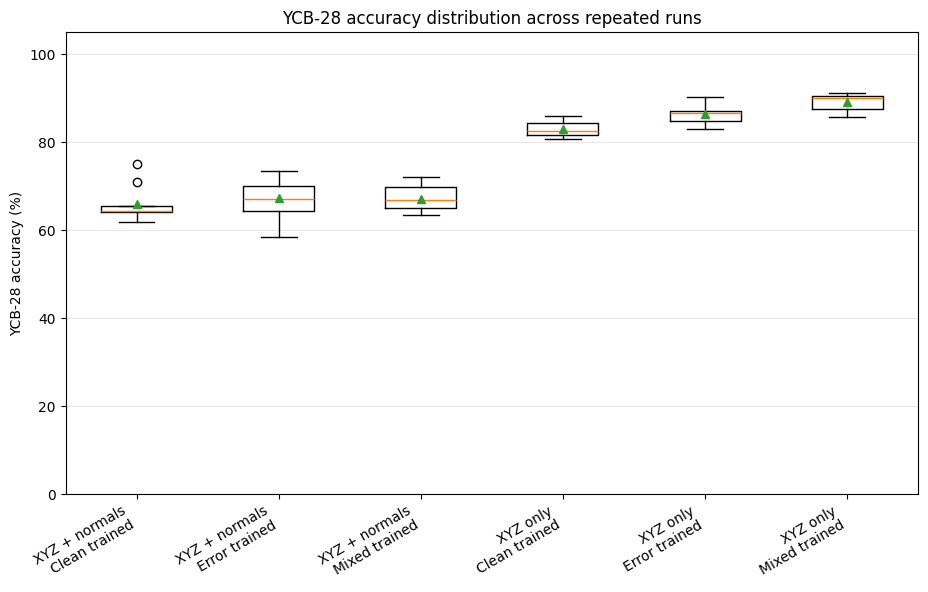

Saved box plot: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/summary_plots/final_ycb28_accuracy_boxplot.png


In [ ]:
# Box plot for YCB-28 results by experiment and condition

ycb_plot_df = ycb_all_results_df.copy()
ycb_plot_df["plot_label"] = ycb_plot_df["input_type"] + "\n" + ycb_plot_df["condition_label"]

labels = []
data = []

for label, group in ycb_plot_df.groupby("plot_label"):
    labels.append(label)
    data.append(group["test_accuracy_percent"].values)

plt.figure(figsize=(11, 6))
plt.boxplot(data, labels=labels, showmeans=True)
plt.ylabel("YCB-28 accuracy (%)")
plt.title("YCB-28 accuracy distribution across repeated runs")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)

boxplot_path = PLOTS_DIR / "final_ycb28_accuracy_boxplot.png"
plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved box plot:", boxplot_path)

In [ ]:
# Select best improved XYZ-only condition based on YCB-28

new_ycb_mean_by_condition = (
    new_ycb_df
    .groupby("train_condition")
    .agg(
        mean_accuracy_percent=("test_accuracy_percent", "mean"),
        std_accuracy_percent=("test_accuracy_percent", "std"),
        min_accuracy_percent=("test_accuracy_percent", "min"),
        max_accuracy_percent=("test_accuracy_percent", "max")
    )
    .reset_index()
    .round(4)
)

display(new_ycb_mean_by_condition)

best_condition = new_ycb_mean_by_condition.loc[
    new_ycb_mean_by_condition["mean_accuracy_percent"].idxmax(),
    "train_condition"
]

best_mean = new_ycb_mean_by_condition.loc[
    new_ycb_mean_by_condition["mean_accuracy_percent"].idxmax(),
    "mean_accuracy_percent"
]

print("Best improved condition:", best_condition)
print("Best mean YCB-28 accuracy:", best_mean)

,train_condition,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,max_accuracy_percent
0,clean_trained_xyz,83.0556,1.8971,80.7143,86.0714
1,error_trained_xyz,86.5476,2.4091,83.0357,90.3571
2,mixed_trained_xyz,89.1865,1.9027,85.7143,91.2500


Best improved condition: mixed_trained_xyz
Best mean YCB-28 accuracy: 89.1865


In [ ]:
# Representative run closest to median accuracy

best_condition_df = new_ycb_df[new_ycb_df["train_condition"] == best_condition].copy()

median_acc = best_condition_df["test_accuracy_percent"].median()

best_condition_df["distance_from_median"] = (
    best_condition_df["test_accuracy_percent"] - median_acc
).abs()

representative_row = best_condition_df.sort_values("distance_from_median").iloc[0]

representative_run = int(representative_row["run_id"])
representative_acc = representative_row["test_accuracy_percent"]

print("Representative condition:", best_condition)
print("Representative run:", representative_run)
print("Representative YCB accuracy:", representative_acc)
print("Median YCB accuracy:", median_acc)

Representative condition: mixed_trained_xyz
Representative run: 7
Representative YCB accuracy: 90.0
Median YCB accuracy: 90.0


In [ ]:
# Confusion matrices

NEW_YCB_CM_DIR = RESULTS_XYZ_DIR / "ycb28_confusion_matrices"
NEW_APS_CM_DIR = RESULTS_XYZ_DIR / "aps_confusion_matrices"

def load_mean_confusion_matrix(cm_dir, train_condition, test_name, run_ids=range(1, 10)):
    matrices = []

    for run_id in run_ids:
        if test_name == "ycb28":
            cm_path = cm_dir / f"{train_condition}_run_{run_id}_ycb28_confusion_matrix.csv"
        else:
            cm_path = cm_dir / f"{train_condition}_run_{run_id}_{test_name}_confusion_matrix.csv"

        if cm_path.exists():
            cm = pd.read_csv(cm_path, index_col=0)
            matrices.append(cm.values)

    if len(matrices) == 0:
        print("No matrices found for:", train_condition, test_name)
        return None

    mean_cm = np.mean(matrices, axis=0)
    return pd.DataFrame(mean_cm, index=CLASS_NAMES, columns=CLASS_NAMES)


def plot_confusion_matrix(cm_df, title, save_path):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm_df.values)
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            plt.text(j, i, f"{cm_df.values[i, j]:.1f}", ha="center", va="center")

    plt.colorbar(label="Average count")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

Average confusion matrix: mixed_trained_xyz on aps_clean_test


,box,cylinder,sphere
box,199.89,0.11,0.0
cylinder,0.00,200.00,0.0
sphere,0.00,0.00,200.0


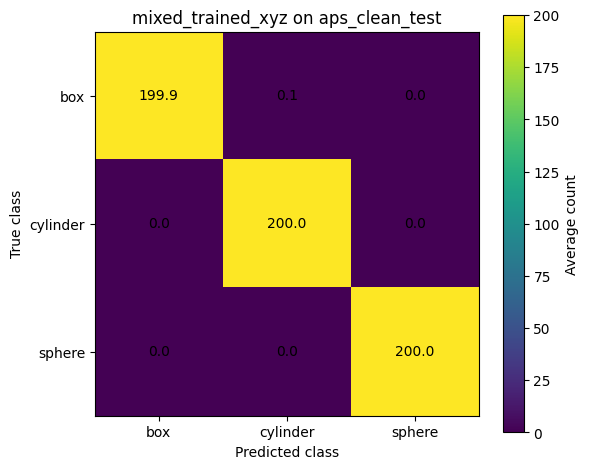

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/confusion_matrices/mixed_trained_xyz_aps_clean_test_average_confusion_matrix.png
Average confusion matrix: mixed_trained_xyz on aps_error_test


,box,cylinder,sphere
box,199.56,0.44,0.0
cylinder,0.00,200.00,0.0
sphere,0.00,0.00,200.0


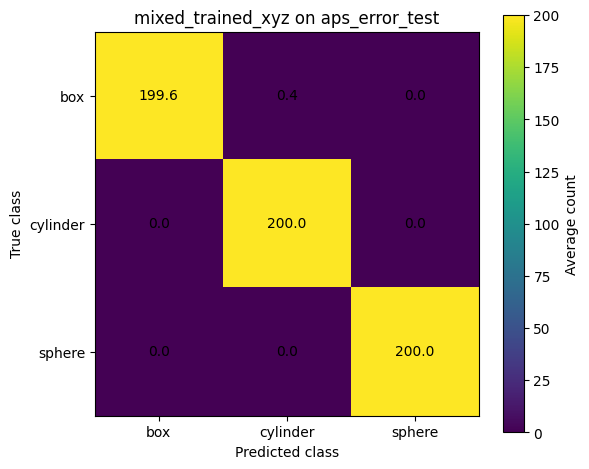

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/confusion_matrices/mixed_trained_xyz_aps_error_test_average_confusion_matrix.png
Average confusion matrix: mixed_trained_xyz on aps_error_double_test


,box,cylinder,sphere
box,195.33,4.67,0.0
cylinder,2.00,198.00,0.0
sphere,0.00,0.00,200.0


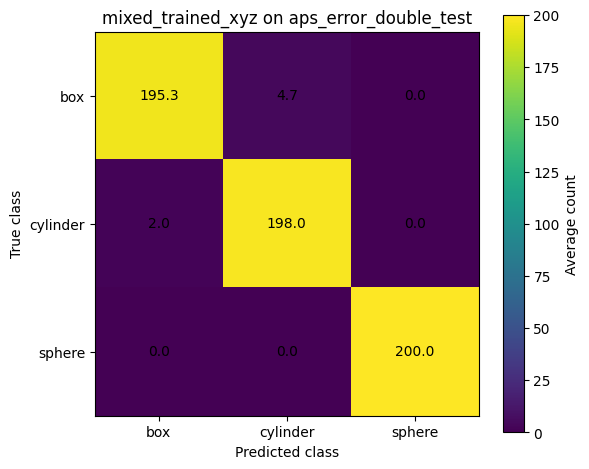

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/confusion_matrices/mixed_trained_xyz_aps_error_double_test_average_confusion_matrix.png
Average confusion matrix: mixed_trained_xyz on YCB-28


,box,cylinder,sphere
box,159.67,20.33,0.00
cylinder,20.11,139.78,0.11
sphere,4.67,15.33,200.00


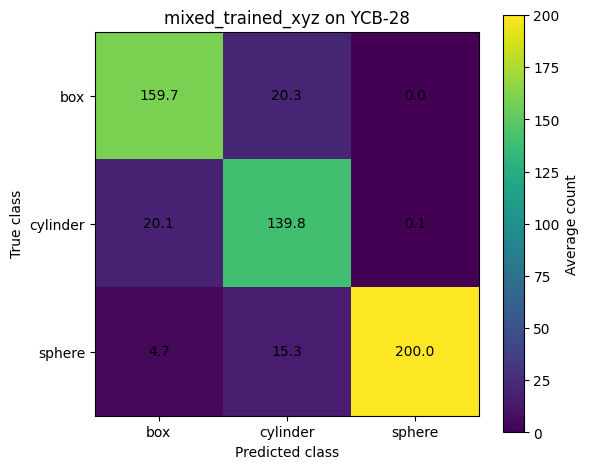

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/confusion_matrices/mixed_trained_xyz_ycb28_average_confusion_matrix.png


In [ ]:
# Plot average confusion matrices for improved best condition

test_sets_to_plot = ["aps_clean_test", "aps_error_test", "aps_error_double_test"]

for test_name in test_sets_to_plot:
    cm_df = load_mean_confusion_matrix(
        cm_dir=NEW_APS_CM_DIR,
        train_condition=best_condition,
        test_name=test_name
    )

    if cm_df is not None:
        print(f"Average confusion matrix: {best_condition} on {test_name}")
        display(cm_df.round(2))

        save_path = CM_PLOTS_DIR / f"{best_condition}_{test_name}_average_confusion_matrix.png"
        plot_confusion_matrix(
            cm_df,
            title=f"{best_condition} on {test_name}",
            save_path=save_path
        )

ycb_cm_df = load_mean_confusion_matrix(
    cm_dir=NEW_YCB_CM_DIR,
    train_condition=best_condition,
    test_name="ycb28"
)

if ycb_cm_df is not None:
    print(f"Average confusion matrix: {best_condition} on YCB-28")
    display(ycb_cm_df.round(2))

    save_path = CM_PLOTS_DIR / f"{best_condition}_ycb28_average_confusion_matrix.png"
    plot_confusion_matrix(
        ycb_cm_df,
        title=f"{best_condition} on YCB-28",
        save_path=save_path
    )

In [ ]:
# YCB-28 object-wise accuracy for best condition

best_ycb_pred_df = new_ycb_pred_df[
    (new_ycb_pred_df["train_condition"] == best_condition)
].copy()

object_accuracy_df = (
    best_ycb_pred_df
    .groupby(["class_name", "object_name"])
    .agg(
        accuracy_percent=("correct", lambda x: x.mean() * 100),
        total_predictions=("correct", "count"),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
    .sort_values(["accuracy_percent", "class_name", "object_name"])
    .round(4)
)

display(object_accuracy_df)

object_accuracy_path = TABLES_DIR / "final_ycb28_objectwise_accuracy_best_condition.csv"
object_accuracy_df.to_csv(object_accuracy_path, index=False)

print("Saved object-wise accuracy:", object_accuracy_path)

print("\nLowest accuracy YCB objects:")
display(object_accuracy_df.head(15))

print("\nHighest accuracy YCB objects:")
display(object_accuracy_df.tail(15))

,class_name,object_name,accuracy_percent,total_predictions,mean_confidence
27,sphere,063_a_marbles,0.0000,180,0.7982
15,cylinder,040_large_marker,32.2222,180,0.7299
5,box,026_sponge,35.0000,180,0.7802
16,cylinder,065_a_cups,85.5556,180,0.8538
3,box,009_gelatin_box,88.3333,180,0.8552
2,box,008_pudding_box,91.1111,180,0.8345
11,cylinder,005_tomato_soup_can,91.6667,180,0.8581
14,cylinder,025_mug,91.6667,180,0.8720
4,box,010_potted_meat_can,93.3333,180,0.8590
1,box,004_sugar_box,96.1111,180,0.9017


Saved object-wise accuracy: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_ycb28_objectwise_accuracy_best_condition.csv

Lowest accuracy YCB objects:


,class_name,object_name,accuracy_percent,total_predictions,mean_confidence
27,sphere,063_a_marbles,0.0000,180,0.7982
15,cylinder,040_large_marker,32.2222,180,0.7299
5,box,026_sponge,35.0000,180,0.7802
16,cylinder,065_a_cups,85.5556,180,0.8538
3,box,009_gelatin_box,88.3333,180,0.8552
2,box,008_pudding_box,91.1111,180,0.8345
11,cylinder,005_tomato_soup_can,91.6667,180,0.8581
14,cylinder,025_mug,91.6667,180,0.8720
4,box,010_potted_meat_can,93.3333,180,0.8590
1,box,004_sugar_box,96.1111,180,0.9017



Highest accuracy YCB objects:


,class_name,object_name,accuracy_percent,total_predictions,mean_confidence
13,cylinder,019_pitcher_base,98.8889,180,0.9542
6,box,036_wood_block,100.0000,180,0.9602
7,box,061_foam_brick,100.0000,180,0.9563
9,cylinder,001_chips_can,100.0000,180,0.9724
12,cylinder,007_tuna_fish_can,100.0000,180,0.9448
17,sphere,012_strawberry,100.0000,180,0.9534
18,sphere,014_lemon,100.0000,180,0.9700
19,sphere,015_peach,100.0000,180,0.9704
20,sphere,017_orange,100.0000,180,0.9730
21,sphere,018_plum,100.0000,180,0.9700


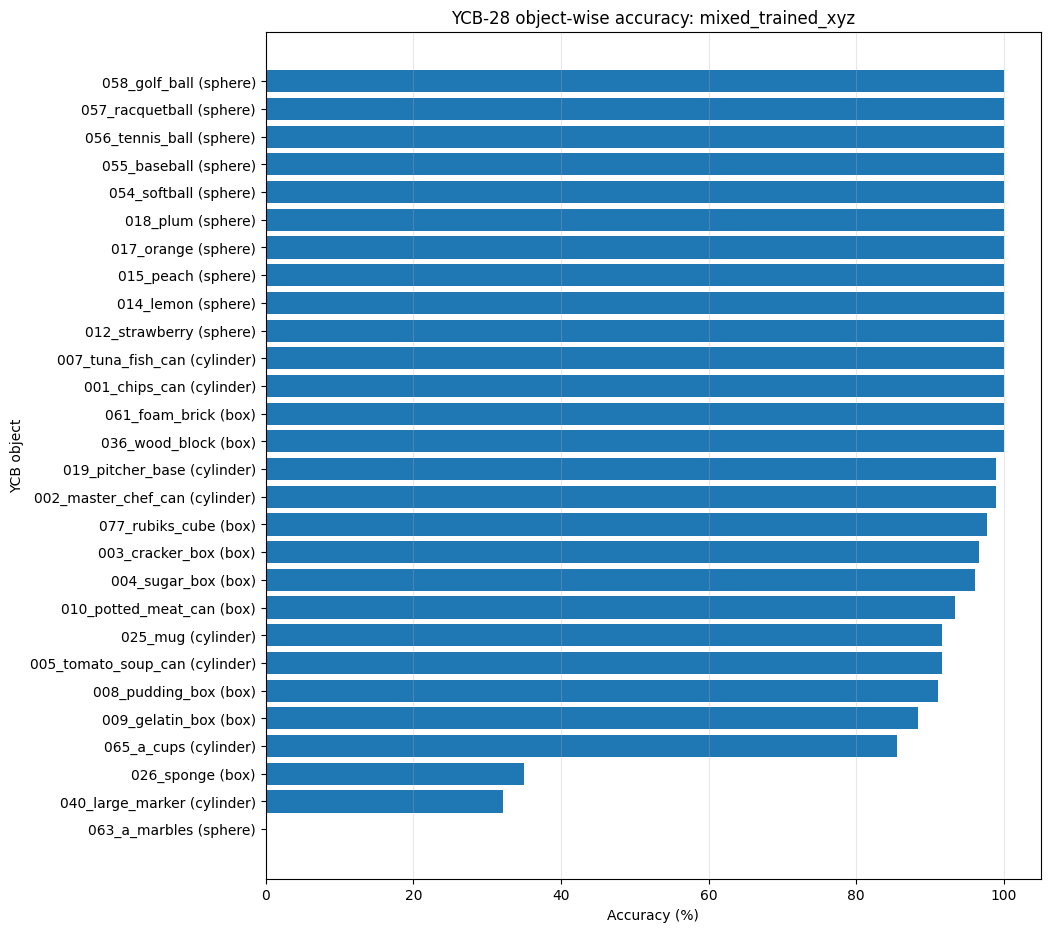

Saved object-wise plot: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/summary_plots/final_ycb28_objectwise_accuracy.png


In [ ]:
# Plot YCB object-wise accuracy

plot_obj_df = object_accuracy_df.sort_values("accuracy_percent", ascending=True).copy()
plot_obj_df["label"] = plot_obj_df["object_name"] + " (" + plot_obj_df["class_name"] + ")"

plt.figure(figsize=(10, 11))
plt.barh(plot_obj_df["label"], plot_obj_df["accuracy_percent"])
plt.xlabel("Accuracy (%)")
plt.ylabel("YCB object")
plt.title(f"YCB-28 object-wise accuracy: {best_condition}")
plt.xlim(0, 105)
plt.grid(axis="x", alpha=0.3)

object_plot_path = PLOTS_DIR / "final_ycb28_objectwise_accuracy.png"
plt.savefig(object_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved object-wise plot:", object_plot_path)

In [ ]:
# Load all training histories and check overfitting

RUN_LOGS_DIR = RESULTS_XYZ_DIR / "run_logs"
history_files = sorted(RUN_LOGS_DIR.glob("*_xyz_run_*_history.csv"))

print("History files found:", len(history_files))

history_dfs = []

for f in history_files:
    df = pd.read_csv(f)
    history_dfs.append(df)

all_history_df = pd.concat(history_dfs, ignore_index=True)

display(all_history_df.head())

overfit_records = []

for (train_condition, run_id), group in all_history_df.groupby(["train_condition", "run_id"]):
    group = group.sort_values("epoch")

    final_row = group.iloc[-1]
    best_row = group.loc[group["val_accuracy"].idxmax()]

    final_train_acc = final_row["train_accuracy"] * 100
    final_val_acc = final_row["val_accuracy"] * 100
    best_val_acc = best_row["val_accuracy"] * 100

    train_val_gap = final_train_acc - final_val_acc

    overfit_records.append({
        "train_condition": train_condition,
        "run_id": int(run_id),
        "final_epoch": int(final_row["epoch"]),
        "final_train_accuracy_percent": final_train_acc,
        "final_val_accuracy_percent": final_val_acc,
        "best_val_accuracy_percent": best_val_acc,
        "train_val_gap_percent": train_val_gap,
        "final_train_loss": final_row["train_loss"],
        "final_val_loss": final_row["val_loss"],
        "possible_overfitting_flag": train_val_gap > 5.0,
        "strong_overfitting_flag": train_val_gap > 10.0
    })

overfit_df = pd.DataFrame(overfit_records).round(4)

display(overfit_df)

overfit_summary = (
    overfit_df
    .groupby("train_condition")
    .agg(
        mean_train_val_gap_percent=("train_val_gap_percent", "mean"),
        max_train_val_gap_percent=("train_val_gap_percent", "max"),
        possible_overfitting_count=("possible_overfitting_flag", "sum"),
        strong_overfitting_count=("strong_overfitting_flag", "sum")
    )
    .reset_index()
    .round(4)
)

display(overfit_summary)

overfit_path = TABLES_DIR / "final_xyz_only_overfitting_check.csv"
overfit_summary_path = TABLES_DIR / "final_xyz_only_overfitting_summary.csv"

overfit_df.to_csv(overfit_path, index=False)
overfit_summary.to_csv(overfit_summary_path, index=False)

print("Saved:", overfit_path)
print("Saved:", overfit_summary_path)

History files found: 27


,train_condition,run_id,seed,epoch,train_loss,train_accuracy,val_loss,val_accuracy,best_val_accuracy_so_far,best_val_loss_so_far,best_epoch_so_far,learning_rate,patience_counter,training_time_min
0,clean_trained_xyz,1,1101,1,0.671527,0.695431,2.635467,0.333333,0.333333,2.635467,1,0.0008,0,6.267605
1,clean_trained_xyz,1,1101,2,0.599633,0.759729,0.813587,0.623333,0.623333,0.813587,2,0.0008,0,6.267605
2,clean_trained_xyz,1,1101,3,0.468646,0.849408,0.387208,0.923333,0.923333,0.387208,3,0.0008,0,6.267605
3,clean_trained_xyz,1,1101,4,0.461700,0.849408,0.419601,0.878333,0.923333,0.387208,3,0.0008,1,6.267605
4,clean_trained_xyz,1,1101,5,0.421360,0.873096,0.317456,0.935000,0.935000,0.317456,5,0.0008,0,6.267605


,train_condition,run_id,final_epoch,final_train_accuracy_percent,final_val_accuracy_percent,best_val_accuracy_percent,train_val_gap_percent,final_train_loss,final_val_loss,possible_overfitting_flag,strong_overfitting_flag
0,clean_trained_xyz,1,50,98.3080,100.0000,100.0,-1.6920,0.2217,0.1729,False,False
1,clean_trained_xyz,2,50,99.4924,100.0000,100.0,-0.5076,0.2053,0.1736,False,False
2,clean_trained_xyz,3,48,99.1540,100.0000,100.0,-0.8460,0.2072,0.1747,False,False
3,clean_trained_xyz,4,50,98.6464,100.0000,100.0,-1.3536,0.2111,0.1721,False,False
4,clean_trained_xyz,5,48,98.6464,100.0000,100.0,-1.3536,0.2210,0.1758,False,False
5,clean_trained_xyz,6,50,99.3232,100.0000,100.0,-0.6768,0.1977,0.1729,False,False
6,clean_trained_xyz,7,50,98.6464,100.0000,100.0,-1.3536,0.2406,0.1747,False,False
7,clean_trained_xyz,8,50,99.1540,100.0000,100.0,-0.8460,0.2049,0.1724,False,False
8,clean_trained_xyz,9,50,98.3080,100.0000,100.0,-1.6920,0.2160,0.1731,False,False
9,error_trained_xyz,1,50,97.6311,100.0000,100.0,-2.3689,0.2381,0.1778,False,False


,train_condition,mean_train_val_gap_percent,max_train_val_gap_percent,possible_overfitting_count,strong_overfitting_count
0,clean_trained_xyz,-1.1468,-0.5076,0,0
1,error_trained_xyz,-2.5796,-0.5406,0,0
2,mixed_trained_xyz,-1.5040,-1.0152,0,0


Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_xyz_only_overfitting_check.csv
Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_xyz_only_overfitting_summary.csv


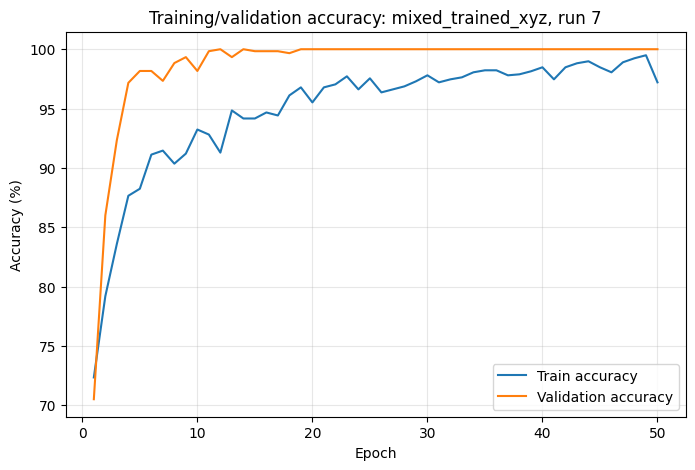

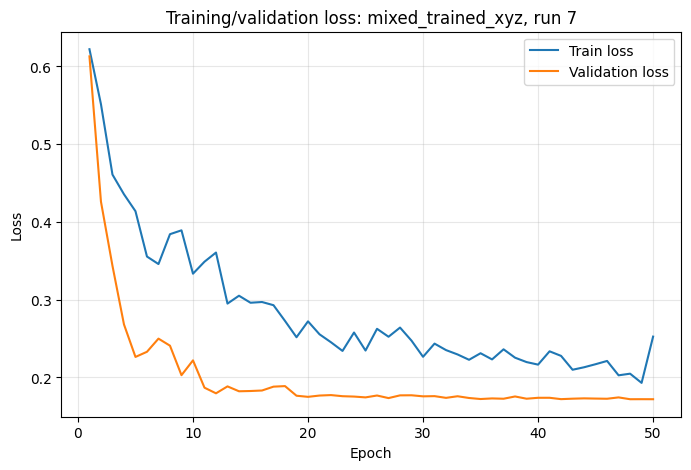

Saved accuracy curve: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/summary_plots/mixed_trained_xyz_run_7_accuracy_curve.png
Saved loss curve: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/summary_plots/mixed_trained_xyz_run_7_loss_curve.png


In [ ]:
# Plot train/validation curves for representative run

rep_history = all_history_df[
    (all_history_df["train_condition"] == best_condition) &
    (all_history_df["run_id"] == representative_run)
].copy()

rep_history = rep_history.sort_values("epoch")

plt.figure(figsize=(8, 5))
plt.plot(rep_history["epoch"], rep_history["train_accuracy"] * 100, label="Train accuracy")
plt.plot(rep_history["epoch"], rep_history["val_accuracy"] * 100, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(f"Training/validation accuracy: {best_condition}, run {representative_run}")
plt.legend()
plt.grid(alpha=0.3)

acc_curve_path = PLOTS_DIR / f"{best_condition}_run_{representative_run}_accuracy_curve.png"
plt.savefig(acc_curve_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(rep_history["epoch"], rep_history["train_loss"], label="Train loss")
plt.plot(rep_history["epoch"], rep_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training/validation loss: {best_condition}, run {representative_run}")
plt.legend()
plt.grid(alpha=0.3)

loss_curve_path = PLOTS_DIR / f"{best_condition}_run_{representative_run}_loss_curve.png"
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved accuracy curve:", acc_curve_path)
print("Saved loss curve:", loss_curve_path)

In [ ]:
# Point-cloud visualisation

def resolve_pointcloud_path(row):
    possible_cols = ["path", "original_drive_path"]

    for col in possible_cols:
        if col in row.index:
            p = Path(str(row[col]))
            if p.exists():
                return p

    raise FileNotFoundError("No valid point-cloud path found for row.")


def load_xyz_from_csv(path):
    data = np.loadtxt(path, delimiter=",")

    if data.ndim == 1:
        data = data.reshape(1, -1)

    xyz = data[:, :3]
    return xyz


def set_axes_equal(ax, xyz):
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    max_range = np.array([
        x.max() - x.min(),
        y.max() - y.min(),
        z.max() - z.min()
    ]).max() / 2.0

    mid_x = (x.max() + x.min()) * 0.5
    mid_y = (y.max() + y.min()) * 0.5
    mid_z = (z.max() + z.min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)


def plot_pointcloud_examples(examples_df, title, save_path, max_points=700):
    n = len(examples_df)

    if n == 0:
        print("No examples to plot:", title)
        return

    cols = min(3, n)
    rows = int(np.ceil(n / cols))

    fig = plt.figure(figsize=(5 * cols, 4.5 * rows))

    for i, (_, row) in enumerate(examples_df.iterrows(), start=1):
        ax = fig.add_subplot(rows, cols, i, projection="3d")

        path = resolve_pointcloud_path(row)
        xyz = load_xyz_from_csv(path)

        if len(xyz) > max_points:
            sample_idx = np.random.choice(len(xyz), max_points, replace=False)
            xyz_plot = xyz[sample_idx]
        else:
            xyz_plot = xyz

        ax.scatter(
            xyz_plot[:, 0],
            xyz_plot[:, 1],
            xyz_plot[:, 2],
            s=3,
            alpha=0.75
        )

        true_class = row.get("true_class", row.get("class_name", "unknown"))
        pred_class = row.get("pred_class", "unknown")
        confidence = row.get("confidence", np.nan)
        object_name = row.get("object_name", Path(str(row.get("path", "sample"))).stem)
        test_set = row.get("test_set", "")

        if pd.notna(confidence):
            subtitle = f"{object_name}\nTrue: {true_class} | Pred: {pred_class}\nConf: {confidence:.3f}"
        else:
            subtitle = f"{object_name}\nTrue: {true_class} | Pred: {pred_class}"

        ax.set_title(subtitle, fontsize=9)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        set_axes_equal(ax, xyz_plot)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

/tmp/ipykernel_513/2736635733.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=42))


,test_set,true_class,pred_class,confidence,correct,path
0,aps_error_double_test,box,box,0.943986,True,/content/pointnetpp_xyz_cache/aps_error_double...
1,aps_error_double_test,cylinder,cylinder,0.970780,True,/content/pointnetpp_xyz_cache/aps_error_double...
2,aps_error_double_test,sphere,sphere,0.980716,True,/content/pointnetpp_xyz_cache/aps_error_double...


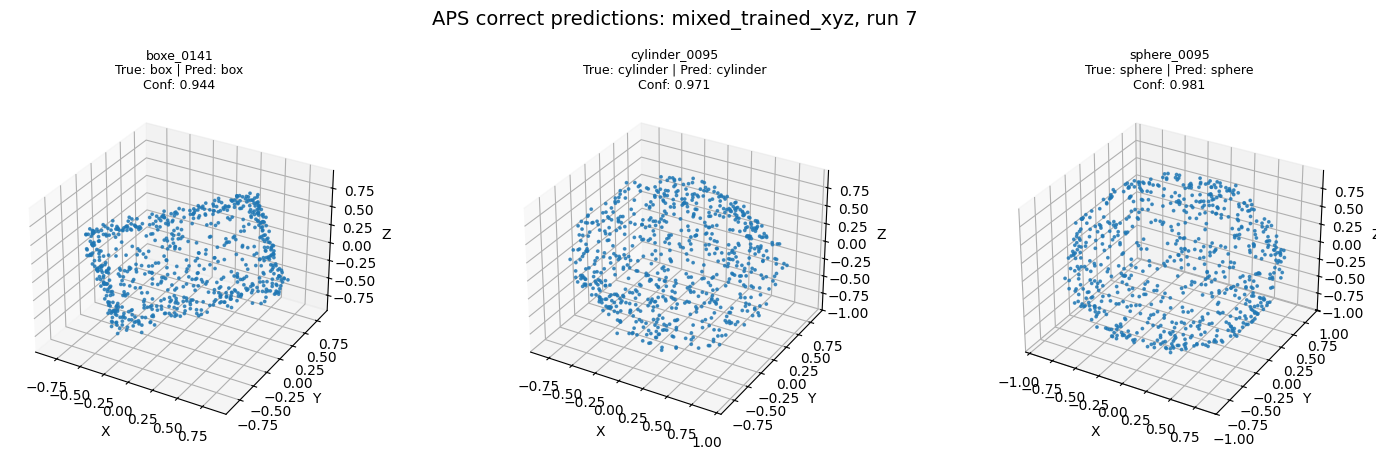

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/pointcloud_visualisations/aps_correct_pointcloud_examples.png


In [ ]:
# APS point-cloud visualisation: correctly classified examples

aps_best_pred_df = new_aps_pred_df[
    (new_aps_pred_df["train_condition"] == best_condition) &
    (new_aps_pred_df["run_id"] == representative_run)
].copy()

# Prefer hardest APS test set for visualisation
aps_visual_test_set = "aps_error_double_test"

aps_vis_df = aps_best_pred_df[
    aps_best_pred_df["test_set"] == aps_visual_test_set
].copy()

aps_correct_examples = (
    aps_vis_df[aps_vis_df["correct"] == True]
    .groupby("true_class", group_keys=False)
    .apply(lambda x: x.sample(1, random_state=42))
    .reset_index(drop=True)
)

display(aps_correct_examples[[
    "test_set", "true_class", "pred_class", "confidence", "correct", "path"
]].head())

aps_correct_path = VIS_DIR / "aps_correct_pointcloud_examples.png"

plot_pointcloud_examples(
    examples_df=aps_correct_examples,
    title=f"APS correct predictions: {best_condition}, run {representative_run}",
    save_path=aps_correct_path
)

,test_set,true_class,pred_class,confidence,correct,path
0,aps_error_double_test,box,cylinder,0.920585,False,/content/pointnetpp_xyz_cache/aps_error_double...
1,aps_error_double_test,box,cylinder,0.617304,False,/content/pointnetpp_xyz_cache/aps_error_double...
2,aps_error_double_test,box,cylinder,0.579621,False,/content/pointnetpp_xyz_cache/aps_error_double...


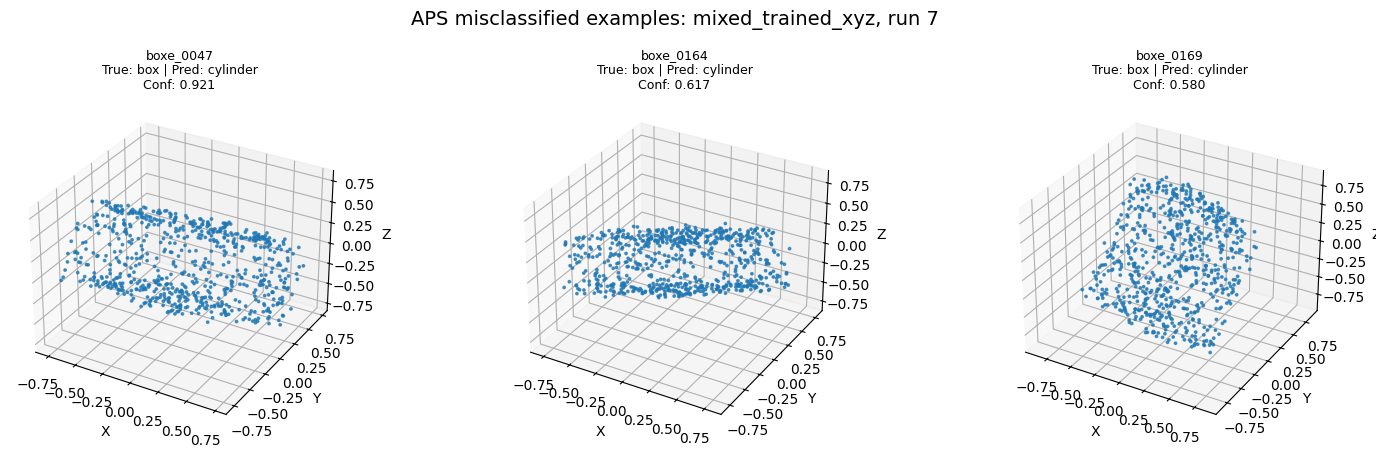

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/pointcloud_visualisations/aps_wrong_pointcloud_examples.png


In [ ]:
# APS point-cloud visualisation: misclassified examples

aps_wrong_examples = aps_vis_df[aps_vis_df["correct"] == False].copy()

if len(aps_wrong_examples) > 0:
    aps_wrong_examples = (
        aps_wrong_examples
        .sort_values("confidence", ascending=False)
        .head(6)
        .reset_index(drop=True)
    )

    display(aps_wrong_examples[[
        "test_set", "true_class", "pred_class", "confidence", "correct", "path"
    ]])

    aps_wrong_path = VIS_DIR / "aps_wrong_pointcloud_examples.png"

    plot_pointcloud_examples(
        examples_df=aps_wrong_examples,
        title=f"APS misclassified examples: {best_condition}, run {representative_run}",
        save_path=aps_wrong_path
    )
else:
    print("No APS misclassified examples found for this representative run and test set.")

/tmp/ipykernel_513/2929257335.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=42))


,object_name,true_class,pred_class,confidence,correct,path
0,026_sponge,box,box,0.656621,True,/content/pointnetpp_xyz_cache/ycb28_test/box/0...
1,019_pitcher_base,cylinder,cylinder,0.967283,True,/content/pointnetpp_xyz_cache/ycb28_test/cylin...
2,018_plum,sphere,sphere,0.970720,True,/content/pointnetpp_xyz_cache/ycb28_test/spher...


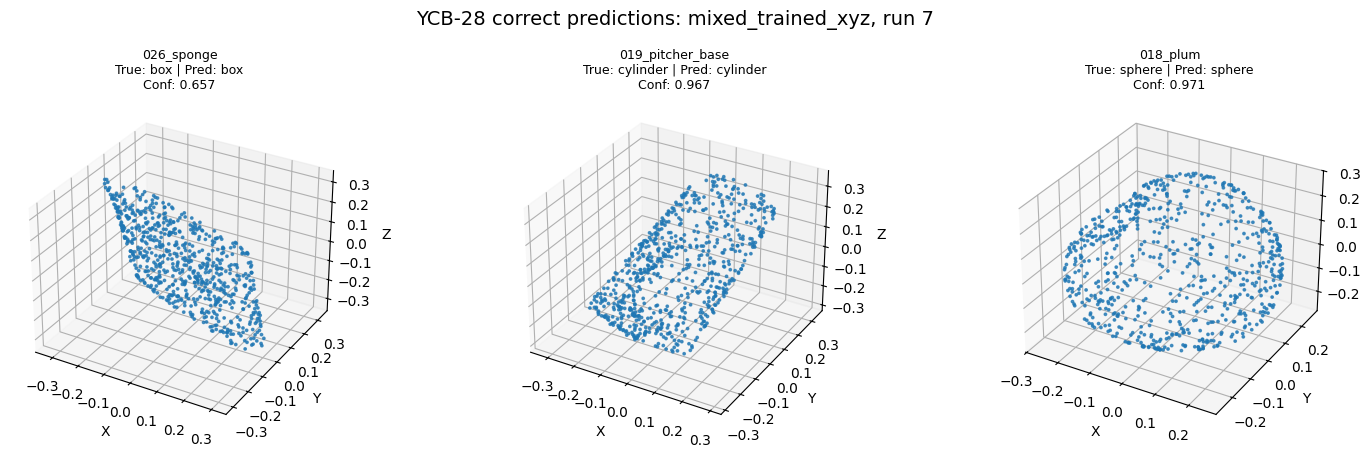

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/pointcloud_visualisations/ycb28_correct_pointcloud_examples.png


In [ ]:
# YCB-28 point-cloud visualisation: correctly classified examples

ycb_best_pred_df = new_ycb_pred_df[
    (new_ycb_pred_df["train_condition"] == best_condition) &
    (new_ycb_pred_df["run_id"] == representative_run)
].copy()

ycb_correct_examples = (
    ycb_best_pred_df[ycb_best_pred_df["correct"] == True]
    .groupby("true_class", group_keys=False)
    .apply(lambda x: x.sample(1, random_state=42))
    .reset_index(drop=True)
)

display(ycb_correct_examples[[
    "object_name", "true_class", "pred_class", "confidence", "correct", "path"
]].head())

ycb_correct_path = VIS_DIR / "ycb28_correct_pointcloud_examples.png"

plot_pointcloud_examples(
    examples_df=ycb_correct_examples,
    title=f"YCB-28 correct predictions: {best_condition}, run {representative_run}",
    save_path=ycb_correct_path
)

,object_name,true_class,pred_class,confidence,correct,path
0,063_a_marbles,sphere,cylinder,0.964363,False,/content/pointnetpp_xyz_cache/ycb28_test/spher...
1,063_a_marbles,sphere,cylinder,0.962986,False,/content/pointnetpp_xyz_cache/ycb28_test/spher...
2,063_a_marbles,sphere,cylinder,0.960808,False,/content/pointnetpp_xyz_cache/ycb28_test/spher...
3,063_a_marbles,sphere,cylinder,0.958839,False,/content/pointnetpp_xyz_cache/ycb28_test/spher...
4,063_a_marbles,sphere,cylinder,0.956732,False,/content/pointnetpp_xyz_cache/ycb28_test/spher...
5,040_large_marker,cylinder,box,0.956323,False,/content/pointnetpp_xyz_cache/ycb28_test/cylin...


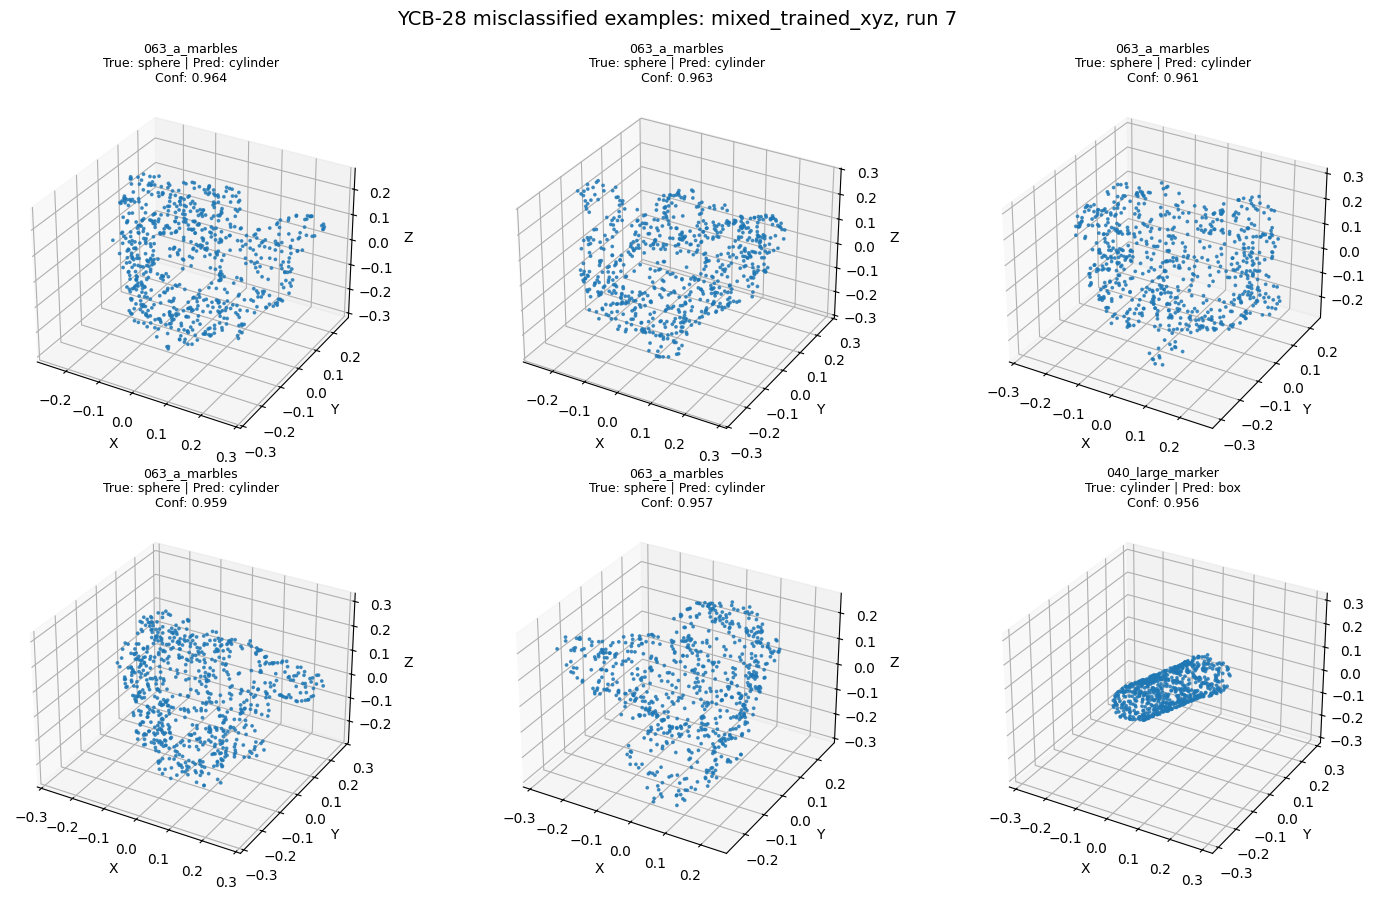

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/pointcloud_visualisations/ycb28_wrong_pointcloud_examples.png


In [ ]:
# YCB-28 point-cloud visualisation: misclassified examples

ycb_wrong_examples = ycb_best_pred_df[ycb_best_pred_df["correct"] == False].copy()

if len(ycb_wrong_examples) > 0:
    # Show confident mistakes because they are useful for discussion
    ycb_wrong_examples = (
        ycb_wrong_examples
        .sort_values("confidence", ascending=False)
        .head(6)
        .reset_index(drop=True)
    )

    display(ycb_wrong_examples[[
        "object_name", "true_class", "pred_class", "confidence", "correct", "path"
    ]])

    ycb_wrong_path = VIS_DIR / "ycb28_wrong_pointcloud_examples.png"

    plot_pointcloud_examples(
        examples_df=ycb_wrong_examples,
        title=f"YCB-28 misclassified examples: {best_condition}, run {representative_run}",
        save_path=ycb_wrong_path
    )
else:
    print("No YCB-28 misclassified examples found for this representative run.")

,object_name,true_class,pred_class,confidence,correct,path
0,008_pudding_box,box,box,0.487369,True,/content/pointnetpp_xyz_cache/ycb28_test/box/0...
1,026_sponge,box,cylinder,0.497837,False,/content/pointnetpp_xyz_cache/ycb28_test/box/0...
2,003_cracker_box,box,box,0.504987,True,/content/pointnetpp_xyz_cache/ycb28_test/box/0...
3,026_sponge,box,box,0.526386,True,/content/pointnetpp_xyz_cache/ycb28_test/box/0...
4,008_pudding_box,box,box,0.533564,True,/content/pointnetpp_xyz_cache/ycb28_test/box/0...
5,008_pudding_box,box,cylinder,0.537419,False,/content/pointnetpp_xyz_cache/ycb28_test/box/0...


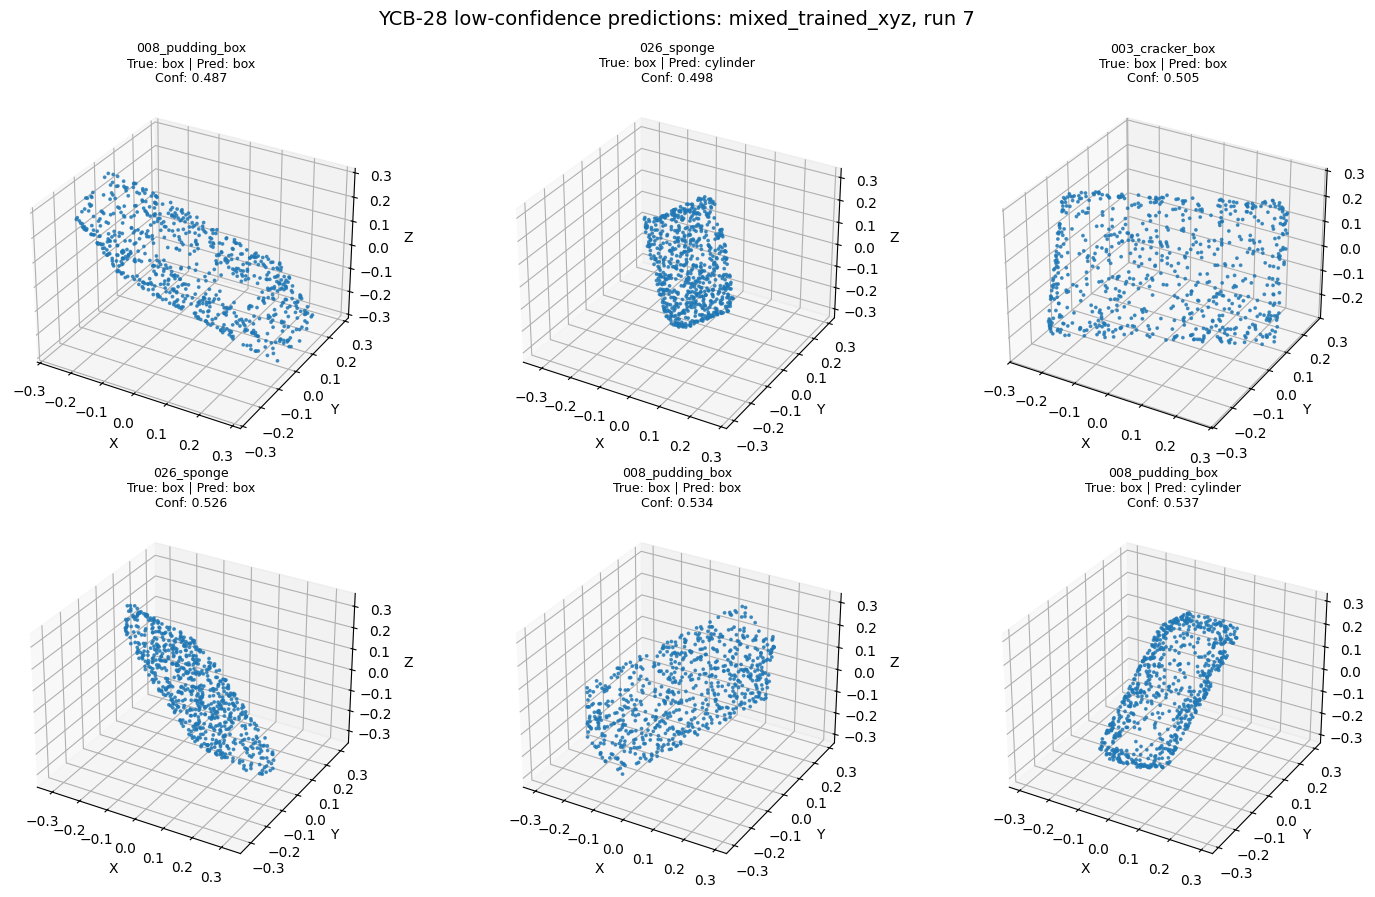

Saved: /content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/pointcloud_visualisations/ycb28_low_confidence_pointcloud_examples.png


In [ ]:
# YCB-28 low-confidence examples

ycb_low_conf_examples = (
    ycb_best_pred_df
    .sort_values("confidence", ascending=True)
    .head(6)
    .reset_index(drop=True)
)

display(ycb_low_conf_examples[[
    "object_name", "true_class", "pred_class", "confidence", "correct", "path"
]])

ycb_low_conf_path = VIS_DIR / "ycb28_low_confidence_pointcloud_examples.png"

plot_pointcloud_examples(
    examples_df=ycb_low_conf_examples,
    title=f"YCB-28 low-confidence predictions: {best_condition}, run {representative_run}",
    save_path=ycb_low_conf_path
)

In [ ]:
# Final interpretation text

old_ycb_mean = None
new_ycb_mean = None

if old_ycb_df is not None:
    old_ycb_mean = old_ycb_df["test_accuracy_percent"].mean()

if new_ycb_df is not None:
    new_ycb_mean = new_ycb_df[new_ycb_df["train_condition"] == best_condition]["test_accuracy_percent"].mean()

interpretation = f"""
Final Results Interpretation

1. The original PointNet++ experiment using XYZ coordinates plus normal vectors achieved very high accuracy on APS synthetic test sets.

2. When the original XYZ + normals models were tested on YCB-28, the performance dropped strongly. This showed a synthetic-to-real transfer gap.

3. A new XYZ-only PointNet++ experiment was then trained using the same APS training logic:
   - APS-clean
   - APS-error
   - APS-clean + APS-error

4. YCB-28 was used only for testing, not for training.

5. The best improved condition was:
   {best_condition}

6. The best improved condition achieved mean YCB-28 accuracy of approximately:
   {new_ycb_mean:.4f}% across repeated runs.

7. The improvement suggests that removing normal-vector input reduced the mismatch between synthetic APS data and real-object YCB meshes.

8. The overfitting check showed no strong overfitting flags based on the train-validation accuracy gap.

9. The point-cloud visualisations show representative correct predictions, misclassified examples and low-confidence YCB-28 examples.
"""

print(interpretation)

interpretation_path = TABLES_DIR / "final_results_interpretation.txt"

with open(interpretation_path, "w") as f:
    f.write(interpretation)

print("Saved interpretation:", interpretation_path)


Final Results Interpretation

1. The original PointNet++ experiment using XYZ coordinates plus normal vectors achieved very high accuracy on APS synthetic test sets.

2. When the original XYZ + normals models were tested on YCB-28, the performance dropped strongly. This showed a synthetic-to-real transfer gap.

3. A new XYZ-only PointNet++ experiment was then trained using the same APS training logic:
   - APS-clean
   - APS-error
   - APS-clean + APS-error

4. YCB-28 was used only for testing, not for training.

5. The best improved condition was:
   mixed_trained_xyz

6. The best improved condition achieved mean YCB-28 accuracy of approximately:
   89.1865% across repeated runs.

7. The improvement suggests that removing normal-vector input reduced the mismatch between synthetic APS data and real-object YCB meshes.

8. The overfitting check showed no strong overfitting flags based on the train-validation accuracy gap.

9. The point-cloud visualisations show representative correct pr

In [ ]:
# Save final notebook status

final_status = {
    "notebook": "07_final_results_analysis_aps_ycb",
    "purpose": "Final combined results analysis for APS and YCB-28",
    "best_condition": best_condition,
    "representative_run": representative_run,
    "final_tables_dir": str(TABLES_DIR),
    "final_figures_dir": str(FIGURES_DIR),
    "pointcloud_visualisation_dir": str(VIS_DIR),
    "files_created": {
        "aps_summary": str(aps_summary_path),
        "ycb_summary": str(ycb_summary_path),
        "aps_five_number": str(aps_five_path),
        "ycb_five_number": str(ycb_five_path),
        "objectwise_accuracy": str(object_accuracy_path),
        "interpretation": str(interpretation_path)
    }
}

status_path = TABLES_DIR / "notebook7_final_analysis_status.json"

with open(status_path, "w") as f:
    json.dump(final_status, f, indent=4)

print("Notebook 7 completed.")
print("Saved status:", status_path)

final_status

Notebook 7 completed.
Saved status: /content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/notebook7_final_analysis_status.json


{'notebook': '07_final_results_analysis_aps_ycb',
 'purpose': 'Final combined results analysis for APS and YCB-28',
 'best_condition': 'mixed_trained_xyz',
 'representative_run': 7,
 'final_tables_dir': '/content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables',
 'final_figures_dir': '/content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis',
 'pointcloud_visualisation_dir': '/content/drive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/pointcloud_visualisations',
 'files_created': {'aps_summary': '/content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_aps_summary_table.csv',
  'ycb_summary': '/content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_ycb28_summary_table.csv',
  'aps_five_number': '/content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_aps_five_number_summary.csv',
  'ycb_five_number': '/content/drive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/final_ycb28_five_number_sum

In [ ]:
# Visualise all majority-correct YCB objects for best condition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math

best_condition = "mixed_trained_xyz"
OBJECT_ACCURACY_THRESHOLD = 50.0   # use 100.0 for only perfectly correct objects
OBJECTS_PER_PAGE = 9
MAX_POINTS = 700

VIS_DIR = FIGURES_DIR / "pointcloud_visualisations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

def get_valid_path(row):
    for col in ["original_drive_path", "path"]:
        if col in row.index:
            p = Path(str(row[col]))
            if p.exists():
                return p
    raise FileNotFoundError("No valid point-cloud path found.")

def load_xyz(path):
    data = np.loadtxt(path, delimiter=",")
    return data[:, :3]

def equal_axes(ax, xyz):
    mins, maxs = xyz.min(axis=0), xyz.max(axis=0)
    centres = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2
    ax.set_xlim(centres[0]-radius, centres[0]+radius)
    ax.set_ylim(centres[1]-radius, centres[1]+radius)
    ax.set_zlim(centres[2]-radius, centres[2]+radius)

# Object-wise accuracy
df = new_ycb_pred_df[new_ycb_pred_df["train_condition"] == best_condition].copy()

obj_acc = (
    df.groupby(["class_name", "object_name"])
    .agg(
        object_accuracy_percent=("correct", lambda x: x.mean() * 100),
        total_predictions=("correct", "count"),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

correct_objects = obj_acc[obj_acc["object_accuracy_percent"] >= OBJECT_ACCURACY_THRESHOLD]

# Pick one correct high-confidence sample per object
examples = (
    df[(df["object_name"].isin(correct_objects["object_name"])) & (df["correct"] == True)]
    .sort_values("confidence", ascending=False)
    .groupby("object_name", as_index=False)
    .first()
    .merge(correct_objects[["object_name", "object_accuracy_percent"]], on="object_name", how="left")
    .sort_values(["true_class", "object_name"])
    .reset_index(drop=True)
)

print(f"Visualising {len(examples)} majority-correct YCB objects out of 28")
display(examples[["object_name", "true_class", "pred_class", "confidence", "object_accuracy_percent"]])

# Plot in pages
num_pages = math.ceil(len(examples) / OBJECTS_PER_PAGE)

for page in range(num_pages):
    page_df = examples.iloc[page*OBJECTS_PER_PAGE:(page+1)*OBJECTS_PER_PAGE]
    cols = 3
    rows = math.ceil(len(page_df) / cols)

    fig = plt.figure(figsize=(15, 4.8 * rows))

    for i, (_, row) in enumerate(page_df.iterrows(), start=1):
        ax = fig.add_subplot(rows, cols, i, projection="3d")

        xyz = load_xyz(get_valid_path(row))

        if len(xyz) > MAX_POINTS:
            idx = np.random.choice(len(xyz), MAX_POINTS, replace=False)
            xyz = xyz[idx]

        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=3, alpha=0.75)

        ax.set_title(
            f"{row['object_name']}\n"
            f"True: {row['true_class']} | Pred: {row['pred_class']}\n"
            f"Obj Acc: {row['object_accuracy_percent']:.1f}% | Conf: {row['confidence']:.3f}",
            fontsize=9
        )

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        equal_axes(ax, xyz)

    plt.suptitle(f"YCB-28 majority-correct objects — {best_condition} — page {page+1}", fontsize=15)
    plt.tight_layout()

    save_path = VIS_DIR / f"ycb28_majority_correct_objects_{best_condition}_page_{page+1}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Extract YCB-28 real object images from the paper PDF figures
# Then save them into data/ycb28/object_images/

!pip install pymupdf pillow -q

from pathlib import Path
from PIL import Image
import fitz
from google.colab import files

PROJECT_DIR = Path("/content/drive/MyDrive/PointNet_APS_Project_V2")
IMAGE_DIR = PROJECT_DIR / "data" / "ycb28" / "object_images"
REF_DIR = PROJECT_DIR / "references"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
REF_DIR.mkdir(parents=True, exist_ok=True)

# Put the JAMT paper PDF here if it already exists in Drive.
PAPER_PDF = REF_DIR / "JAMT_PointNet_YCB.pdf"

if not PAPER_PDF.exists():
    print("Upload the JAMT paper PDF now.")
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    uploaded_path = Path(uploaded_name)
    import shutil
    shutil.copy2(str(uploaded_path), str(PAPER_PDF))

print("Using paper PDF:", PAPER_PDF)

# Render required pages at 2x resolution.
# In the PDF: page 5 = boxes, page 6 = cylinders, page 7 = spheres
doc = fitz.open(str(PAPER_PDF))
zoom = 2
mat = fitz.Matrix(zoom, zoom)

rendered_pages = {}
for page_number in [5, 6, 7]:
    page = doc[page_number - 1]
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img_path = REF_DIR / f"jmat_page_{page_number}.png"
    pix.save(str(img_path))
    rendered_pages[page_number] = Image.open(img_path).convert("RGB")
    print(f"Rendered page {page_number}:", img_path, rendered_pages[page_number].size)

# Crop boxes are based on 2x rendered pages, size approx 1191 x 1582.
# Coordinates: (left, upper, right, lower)
# These crop only the real object photos, not the grey mesh images.

crop_boxes = {
    # Page 5: box-like objects
    "003_cracker_box":       (365, 1028, 455, 1125, 5),
    "004_sugar_box":         (552, 1028, 625, 1125, 5),
    "008_pudding_box":       (724, 1028, 810, 1125, 5),
    "009_gelatin_box":       (905, 1028, 985, 1125, 5),
    "010_potted_meat_can":   (370, 1160, 455, 1258, 5),
    "026_sponge":            (555, 1160, 695, 1255, 5),
    "036_wood_block":        (858, 1160, 950, 1260, 5),
    "061_foam_brick":        (510, 1292, 610, 1390, 5),
    "077_rubiks_cube":       (722, 1292, 820, 1390, 5),

    # Page 6: cylinder-like objects
    "001_chips_can":         (375, 115, 455, 205, 6),
    "002_master_chef_can":   (515, 115, 610, 205, 6),
    "005_tomato_soup_can":   (685, 115, 765, 205, 6),
    "007_tuna_fish_can":     (855, 115, 965, 205, 6),
    "025_mug":               (360, 238, 455, 330, 6),
    "019_pitcher_base":      (530, 238, 625, 330, 6),
    "040_large_marker":      (705, 238, 825, 330, 6),
    "065_a_cups":            (900, 238, 985, 330, 6),

    # Page 7: sphere-like objects
    "012_strawberry":        (365, 112, 448, 198, 7),
    "014_lemon":             (552, 112, 630, 198, 7),
    "015_peach":             (730, 112, 812, 198, 7),
    "017_orange":            (914, 112, 995, 198, 7),
    "018_plum":              (365, 232, 448, 318, 7),
    "054_softball":          (550, 232, 632, 318, 7),
    "055_baseball":          (735, 232, 815, 318, 7),
    "056_tennis_ball":       (915, 232, 995, 318, 7),
    "057_racquetball":       (365, 352, 448, 438, 7),
    "058_golf_ball":         (552, 352, 630, 438, 7),
    "063_a_marbles":         (735, 352, 815, 438, 7),
}

saved = []

for object_name, (left, upper, right, lower, page_number) in crop_boxes.items():
    page_img = rendered_pages[page_number]
    crop = page_img.crop((left, upper, right, lower))

    # Add small white padding
    padded = Image.new("RGB", (crop.width + 20, crop.height + 20), "white")
    padded.paste(crop, (10, 10))

    out_path = IMAGE_DIR / f"{object_name}.jpg"
    padded.save(out_path, quality=95)
    saved.append(out_path)

print(f"\nSaved {len(saved)} object images to:")
print(IMAGE_DIR)

for p in saved:
    print(p.name)

Upload the JAMT paper PDF now.


Saving JAMT - Primitive Shape Recognition from Real-Life Scenes Using the PointNet Deep ANN.pdf to JAMT - Primitive Shape Recognition from Real-Life Scenes Using the PointNet Deep ANN (1).pdf
Using paper PDF: /content/drive/MyDrive/PointNet_APS_Project_V2/references/JAMT_PointNet_YCB.pdf
Rendered page 5: /content/drive/MyDrive/PointNet_APS_Project_V2/references/jmat_page_5.png (1191, 1582)
Rendered page 6: /content/drive/MyDrive/PointNet_APS_Project_V2/references/jmat_page_6.png (1191, 1582)
Rendered page 7: /content/drive/MyDrive/PointNet_APS_Project_V2/references/jmat_page_7.png (1191, 1582)

Saved 28 object images to:
/content/drive/MyDrive/PointNet_APS_Project_V2/data/ycb28/object_images
003_cracker_box.jpg
004_sugar_box.jpg
008_pudding_box.jpg
009_gelatin_box.jpg
010_potted_meat_can.jpg
026_sponge.jpg
036_wood_block.jpg
061_foam_brick.jpg
077_rubiks_cube.jpg
001_chips_can.jpg
002_master_chef_can.jpg
005_tomato_soup_can.jpg
007_tuna_fish_can.jpg
025_mug.jpg
019_pitcher_base.jpg
040

In [ ]:
# Final all-28 YCB visualisation:
# Left = real YCB object image cropped from paper
# Right = PointNet++ input point cloud with prediction result

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math
from PIL import Image

# -----------------------------
# Settings
# -----------------------------
PROJECT_DIR = Path("/content/drive/MyDrive/PointNet_APS_Project_V2")
IMAGE_DIR = PROJECT_DIR / "data" / "ycb28" / "object_images"

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = PROJECT_DIR / "figures_final_analysis"

VIS_DIR = FIGURES_DIR / "pointcloud_visualisations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

best_condition = "mixed_trained_xyz"
OBJECTS_PER_PAGE = 6
MAX_POINTS = 700

print("Checking image folder:", IMAGE_DIR)
image_files = sorted(IMAGE_DIR.glob("*.jpg"))
print("Number of real object images found:", len(image_files))

# -----------------------------
# Helper functions
# -----------------------------
def get_image_path(object_name):
    possible_names = [
        object_name,
        object_name.replace("-", "_"),
        object_name.replace("_", "-")
    ]

    for name in possible_names:
        for ext in [".jpg", ".jpeg", ".png", ".webp"]:
            p = IMAGE_DIR / f"{name}{ext}"
            if p.exists():
                return p

    return None

def get_pc_path(row):
    for col in ["original_drive_path", "path"]:
        if col in row.index:
            p = Path(str(row[col]))
            if p.exists():
                return p

    raise FileNotFoundError(f"No valid point-cloud path found for {row.get('object_name', 'unknown')}")

def load_xyz(path):
    data = np.loadtxt(path, delimiter=",")
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data[:, :3]

def equal_axes(ax, xyz):
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    centres = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2

    ax.set_xlim(centres[0] - radius, centres[0] + radius)
    ax.set_ylim(centres[1] - radius, centres[1] + radius)
    ax.set_zlim(centres[2] - radius, centres[2] + radius)

# -----------------------------
# Prepare one representative sample per YCB object
# -----------------------------
df = new_ycb_pred_df[new_ycb_pred_df["train_condition"] == best_condition].copy()

obj_acc = (
    df.groupby(["class_name", "object_name"])
    .agg(
        object_accuracy_percent=("correct", lambda x: x.mean() * 100),
        total_predictions=("correct", "count"),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

examples_list = []

for object_name, group in df.groupby("object_name"):
    group = group.copy()
    correct_group = group[group["correct"] == True]

    # choose highest-confidence correct sample if available,
    # otherwise choose highest-confidence wrong sample
    if len(correct_group) > 0:
        selected = correct_group.sort_values("confidence", ascending=False).iloc[0]
    else:
        selected = group.sort_values("confidence", ascending=False).iloc[0]

    examples_list.append(selected)

examples = pd.DataFrame(examples_list).reset_index(drop=True)

examples = examples.merge(
    obj_acc[["object_name", "object_accuracy_percent", "total_predictions", "mean_confidence"]],
    on="object_name",
    how="left"
)

examples = examples.sort_values(["true_class", "object_name"]).reset_index(drop=True)

print("Total YCB objects selected:", len(examples))
display(examples[[
    "object_name",
    "true_class",
    "pred_class",
    "correct",
    "confidence",
    "object_accuracy_percent",
    "total_predictions"
]])

# -----------------------------
# Plot all 28 objects
# -----------------------------
num_pages = math.ceil(len(examples) / OBJECTS_PER_PAGE)
saved_paths = []

for page in range(num_pages):
    page_df = examples.iloc[page * OBJECTS_PER_PAGE:(page + 1) * OBJECTS_PER_PAGE]
    rows = len(page_df)

    fig = plt.figure(figsize=(12, 4.3 * rows))

    for i, (_, row) in enumerate(page_df.iterrows()):
        object_name = row["object_name"]
        true_class = row["true_class"]
        pred_class = row["pred_class"]
        correct = row["correct"]
        confidence = row["confidence"]
        object_accuracy = row["object_accuracy_percent"]

        # Left: real object image
        ax_img = fig.add_subplot(rows, 2, 2 * i + 1)
        img_path = get_image_path(object_name)

        if img_path is not None:
            img = Image.open(img_path)
            ax_img.imshow(img)
            ax_img.set_title(f"Real YCB object\n{object_name}", fontsize=10)
        else:
            ax_img.text(
                0.5, 0.5,
                f"Image missing\n{object_name}",
                ha="center",
                va="center",
                fontsize=9
            )
            ax_img.set_title(f"Image missing\n{object_name}", fontsize=10)

        ax_img.axis("off")

        # Right: PointNet++ input point cloud
        ax_pc = fig.add_subplot(rows, 2, 2 * i + 2, projection="3d")

        xyz = load_xyz(get_pc_path(row))

        if len(xyz) > MAX_POINTS:
            idx = np.random.choice(len(xyz), MAX_POINTS, replace=False)
            xyz = xyz[idx]

        ax_pc.scatter(
            xyz[:, 0],
            xyz[:, 1],
            xyz[:, 2],
            s=3,
            alpha=0.75
        )

        status = "Correct" if correct else "Wrong"

        ax_pc.set_title(
            f"PointNet++ input point cloud\n"
            f"True: {true_class} | Pred: {pred_class} | {status}\n"
            f"Object Acc: {object_accuracy:.1f}% | Conf: {confidence:.3f}",
            fontsize=10
        )

        ax_pc.set_xlabel("X")
        ax_pc.set_ylabel("Y")
        ax_pc.set_zlabel("Z")
        equal_axes(ax_pc, xyz)

    plt.suptitle(
        f"YCB-28 real object image vs PointNet++ point cloud — {best_condition} — page {page + 1}",
        fontsize=14
    )

    plt.tight_layout()

    save_path = VIS_DIR / f"ycb28_real_image_vs_pointcloud_all28_{best_condition}_page_{page + 1}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    saved_paths.append(save_path)
    print("Saved:", save_path)

print("\nCompleted.")
print("Pages saved:", len(saved_paths))
for p in saved_paths:
    print(p)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Mann-Whitney U test for YCB-28 experiment comparisons

import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import mannwhitneyu, kruskal

PROJECT_DIR = Path("/content/drive/MyDrive/PointNet_APS_Project_V2")

old_ycb_path = PROJECT_DIR / "results_final" / "ycb28_results" / "pointnetpp_aps_to_ycb28_summary_runs_1_to_9.csv"
new_ycb_path = PROJECT_DIR / "results_final_xyz" / "ycb28_results" / "pointnetpp_xyz_aps_to_ycb28_summary_runs.csv"

old_ycb = pd.read_csv(old_ycb_path)
new_ycb = pd.read_csv(new_ycb_path)

def standardise_accuracy_column(df):
    df = df.copy()

    if "test_accuracy_percent" in df.columns:
        pass
    elif "accuracy_percent" in df.columns:
        df["test_accuracy_percent"] = df["accuracy_percent"]
    elif "test_accuracy" in df.columns:
        df["test_accuracy_percent"] = df["test_accuracy"] * 100
    elif "accuracy" in df.columns:
        df["test_accuracy_percent"] = df["accuracy"] * 100
    else:
        raise ValueError("No accuracy column found.")

    return df

def get_base_condition(name):
    name = str(name).lower()

    if "mixed" in name:
        return "Mixed"
    elif "error" in name:
        return "Error"
    elif "clean" in name:
        return "Clean"
    else:
        return "Unknown"

old_ycb = standardise_accuracy_column(old_ycb)
new_ycb = standardise_accuracy_column(new_ycb)

old_ycb["experiment"] = "Original PointNet++ XYZ + normals"
new_ycb["experiment"] = "Improved PointNet++ XYZ only"

old_ycb["base_condition"] = old_ycb["train_condition"].apply(get_base_condition)
new_ycb["base_condition"] = new_ycb["train_condition"].apply(get_base_condition)

ycb_all = pd.concat([old_ycb, new_ycb], ignore_index=True)

display(ycb_all[["experiment", "base_condition", "train_condition", "test_accuracy_percent"]].head())

# -----------------------------
# Helper functions
# -----------------------------

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    greater = 0
    less = 0

    for xi in x:
        greater += np.sum(xi > y)
        less += np.sum(xi < y)

    return (greater - less) / (len(x) * len(y))

def holm_bonferroni(p_values):
    p_values = np.asarray(p_values)
    m = len(p_values)
    order = np.argsort(p_values)

    adjusted = np.empty(m)

    for rank, idx in enumerate(order):
        adjusted[idx] = min((m - rank) * p_values[idx], 1.0)

    # Make adjusted p-values monotonic
    for i in range(1, m):
        adjusted[order[i]] = max(adjusted[order[i]], adjusted[order[i - 1]])

    return adjusted

def mann_whitney_pairwise(df, group_col, value_col, pairs, comparison_name):
    results = []

    for group_a, group_b in pairs:
        x = df[df[group_col] == group_a][value_col].dropna().values
        y = df[df[group_col] == group_b][value_col].dropna().values

        if len(x) == 0 or len(y) == 0:
            continue

        u_stat, p_value = mannwhitneyu(
            x,
            y,
            alternative="two-sided",
            method="auto"
        )

        delta = cliffs_delta(x, y)

        results.append({
            "comparison_set": comparison_name,
            "group_a": group_a,
            "group_b": group_b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.median(x),
            "median_b": np.median(y),
            "mean_a": np.mean(x),
            "mean_b": np.mean(y),
            "mann_whitney_u": u_stat,
            "p_value": p_value,
            "cliffs_delta": delta
        })

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        results_df["p_value_holm"] = holm_bonferroni(results_df["p_value"].values)
        results_df["significant_0_05"] = results_df["p_value_holm"] < 0.05

    return results_df

# -----------------------------
# Test 1: Original vs Improved for each condition
# -----------------------------

model_comparison_results = []

for condition in ["Clean", "Error", "Mixed"]:
    subset = ycb_all[ycb_all["base_condition"] == condition].copy()

    result = mann_whitney_pairwise(
        df=subset,
        group_col="experiment",
        value_col="test_accuracy_percent",
        pairs=[("Original PointNet++ XYZ + normals", "Improved PointNet++ XYZ only")],
        comparison_name=f"Original vs Improved - {condition}"
    )

    model_comparison_results.append(result)

model_comparison_results = pd.concat(model_comparison_results, ignore_index=True)

print("Mann-Whitney U: Original XYZ+normals vs Improved XYZ-only")
display(model_comparison_results)

# -----------------------------
# Test 2: Clean vs Error vs Mixed within final XYZ-only model
# -----------------------------

xyz_only = ycb_all[ycb_all["experiment"] == "Improved PointNet++ XYZ only"].copy()

# Optional overall Kruskal-Wallis test across 3 groups
clean_vals = xyz_only[xyz_only["base_condition"] == "Clean"]["test_accuracy_percent"].values
error_vals = xyz_only[xyz_only["base_condition"] == "Error"]["test_accuracy_percent"].values
mixed_vals = xyz_only[xyz_only["base_condition"] == "Mixed"]["test_accuracy_percent"].values

h_stat, kruskal_p = kruskal(clean_vals, error_vals, mixed_vals)

print("\nKruskal-Wallis test across Clean, Error and Mixed for improved XYZ-only model:")
print("H statistic:", h_stat)
print("p-value:", kruskal_p)

condition_comparison_results = mann_whitney_pairwise(
    df=xyz_only,
    group_col="base_condition",
    value_col="test_accuracy_percent",
    pairs=[
        ("Clean", "Error"),
        ("Clean", "Mixed"),
        ("Error", "Mixed")
    ],
    comparison_name="Improved XYZ-only condition comparison"
)

print("\nMann-Whitney U: Clean vs Error vs Mixed within improved XYZ-only model")
display(condition_comparison_results)

# -----------------------------
# Save statistical test results
# -----------------------------

stats_dir = PROJECT_DIR / "results_final_xyz" / "statistics"
stats_dir.mkdir(parents=True, exist_ok=True)

model_stats_path = stats_dir / "mann_whitney_ycb_original_vs_improved.csv"
condition_stats_path = stats_dir / "mann_whitney_ycb_clean_error_mixed_xyz_only.csv"

model_comparison_results.to_csv(model_stats_path, index=False)
condition_comparison_results.to_csv(condition_stats_path, index=False)

print("\nSaved:")
print(model_stats_path)
print(condition_stats_path)

,experiment,base_condition,train_condition,test_accuracy_percent
0,Original PointNet++ XYZ + normals,Clean,clean_trained,65.535714
1,Original PointNet++ XYZ + normals,Clean,clean_trained,62.857143
2,Original PointNet++ XYZ + normals,Clean,clean_trained,64.285714
3,Original PointNet++ XYZ + normals,Clean,clean_trained,65.357143
4,Original PointNet++ XYZ + normals,Clean,clean_trained,75.000000


Mann-Whitney U: Original XYZ+normals vs Improved XYZ-only


,comparison_set,group_a,group_b,n_a,n_b,median_a,median_b,mean_a,mean_b,mann_whitney_u,p_value,cliffs_delta,p_value_holm,significant_0_05
0,Original vs Improved - Clean,Original PointNet++ XYZ + normals,Improved PointNet++ XYZ only,9,9,64.464286,82.678571,66.051587,83.055556,0.0,0.000412,-1.0,0.000412,True
1,Original vs Improved - Error,Original PointNet++ XYZ + normals,Improved PointNet++ XYZ only,9,9,67.142857,86.607143,67.321429,86.547619,0.0,0.000407,-1.0,0.000407,True
2,Original vs Improved - Mixed,Original PointNet++ XYZ + normals,Improved PointNet++ XYZ only,9,9,66.964286,90.000000,67.182540,89.186508,0.0,0.000407,-1.0,0.000407,True



Kruskal-Wallis test across Clean, Error and Mixed for improved XYZ-only model:
H statistic: 16.64268487380685
p-value: 0.00024326907154631396

Mann-Whitney U: Clean vs Error vs Mixed within improved XYZ-only model


,comparison_set,group_a,group_b,n_a,n_b,median_a,median_b,mean_a,mean_b,mann_whitney_u,p_value,cliffs_delta,p_value_holm,significant_0_05
0,Improved XYZ-only condition comparison,Clean,Error,9,9,82.678571,86.607143,83.055556,86.547619,9.0,0.006167,-0.777778,0.012334,True
1,Improved XYZ-only condition comparison,Clean,Mixed,9,9,82.678571,90.000000,83.055556,89.186508,1.0,0.000574,-0.975309,0.001721,True
2,Improved XYZ-only condition comparison,Error,Mixed,9,9,86.607143,90.000000,86.547619,89.186508,14.0,0.021346,-0.654321,0.021346,True



Saved:
/content/drive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/statistics/mann_whitney_ycb_original_vs_improved.csv
/content/drive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/statistics/mann_whitney_ycb_clean_error_mixed_xyz_only.csv
